# Tugas Analisis Multimedia: **Image (Citra Digital)**

**Mata Kuliah:** Pengolahan Citra  
**Nama:** Bella Agustina  
**NIM:** 122400087   

---

## Deskripsi Tugas

Tugas ini bertujuan untuk memahami **representasi dasar data citra digital (image)** melalui praktik langsung memuat data, visualisasi komponen warna, serta melakukan analisis spasial sederhana menggunakan berbagai teknik dasar pengolahan citra.

Anda akan bekerja dengan satu atau beberapa gambar (foto diri, objek, atau lingkungan sekitar) untuk:

* Mengamati struktur data piksel dan channel warna (RGB, Grayscale, HSV, dsb.)
* Menganalisis perbedaan hasil visualisasi antar representasi warna.
* Melakukan eksplorasi sederhana terhadap transformasi citra (cropping, filtering, edge detection, dll.)
* Menyimpulkan pengaruh setiap tahap pemrosesan terhadap persepsi visual

Fokus tugas ini adalah pada **pemahaman konsep representasi spasial citra digital** dan **interpretasi hasil visualisasi**, **bukan** pada manipulasi kompleks atau penerapan model pembelajaran mesin.

### **Soal 1 — Cropping dan Konversi Warna**

* Ambil sebuah gambar diri Anda (*selfie*) menggunakan kamera atau smartphone.
* Lakukan **cropping secara manual** untuk menghasilkan dua potongan:

  * Cropping **kotak persegi pada area wajah**.
  * Cropping **persegi panjang pada area latar belakang**.
* Resize hasil crop menjadi **920×920 piksel**.
* Konversi gambar menjadi **grayscale** dan **HSV**, lalu tampilkan ketiganya berdampingan.
* Tambahkan **anotasi teks** berisi nama Anda di atas kepala pada gambar hasil crop.

  * Gaya teks (font, warna, posisi, ukuran, ketebalan) **dibebaskan**.
* Jelaskan efek **cropping** dan **perubahan warna** menggunakan **Markdown**.


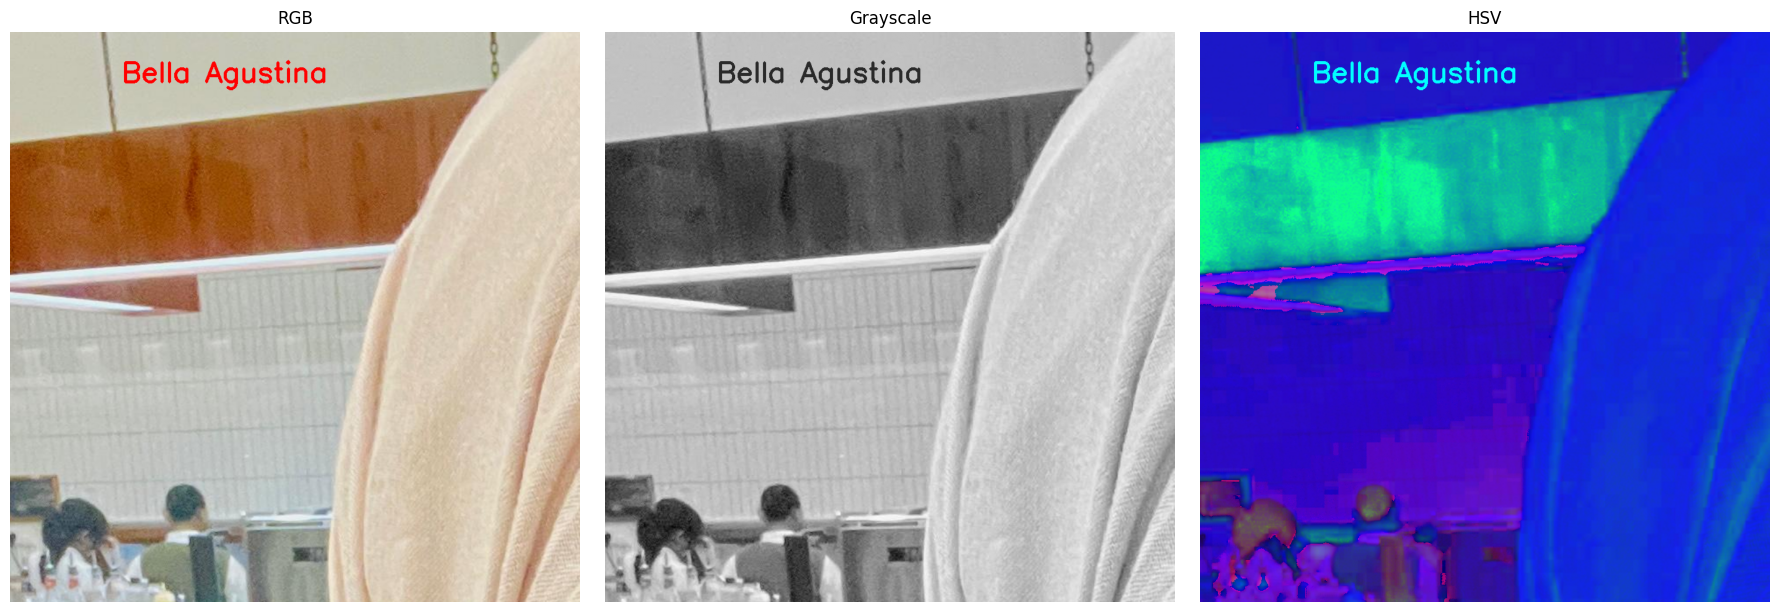

In [34]:
import cv2
import matplotlib.pyplot as plt

# Membaca gambar
img = cv2.imread(r".\assests_ws4\selfie11.jpeg")

# Cek apakah gambar berhasil dibaca
if img is None:
    print("Gambar gagal dibaca")
else:

    # Konversi BGR ke RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Crop wajah
    crop_wajah = img_rgb[200:900, 50:700]

    # Resize
    crop_wajah = cv2.resize(crop_wajah, (920, 920))

    # Tambahkan teks
    cv2.putText(
        crop_wajah,
        "Bella Agustina",
        (180, 80),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.5,
        (255, 0, 0),
        3
    )

    # Konversi warna
    gray = cv2.cvtColor(crop_wajah, cv2.COLOR_RGB2GRAY)
    hsv = cv2.cvtColor(crop_wajah, cv2.COLOR_RGB2HSV)

    # Tampilkan hasil
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    axs[0].imshow(crop_wajah)
    axs[0].set_title("RGB")
    axs[0].axis('off')

    axs[1].imshow(gray, cmap='gray')
    axs[1].set_title("Grayscale")
    axs[1].axis('off')

    axs[2].imshow(hsv)
    axs[2].set_title("HSV")
    axs[2].axis('off')

    plt.tight_layout()
    plt.show()

Pada kode tersebut dilakukan proses cropping wajah dan konversi warna pada gambar selfie menggunakan OpenCV. Tahap pertama dimulai dengan membaca gambar menggunakan `cv2.imread()`. Setelah gambar berhasil dibaca, gambar dikonversi dari format BGR ke RGB menggunakan `cv2.cvtColor()` agar warna dapat ditampilkan dengan benar pada matplotlib. Konversi ini penting karena OpenCV secara default menggunakan format BGR, sedangkan matplotlib menggunakan format RGB.

Selanjutnya dilakukan cropping pada area wajah menggunakan koordinat array `[200:900, 50:700]`. Teknik cropping digunakan untuk mengambil bagian tertentu dari gambar sehingga fokus citra hanya berada pada area wajah pengguna. Setelah proses crop selesai, gambar di-resize menjadi ukuran 920×920 piksel menggunakan `cv2.resize()` agar ukuran gambar menjadi lebih seragam dan mudah ditampilkan.

Pada hasil crop wajah kemudian ditambahkan anotasi teks berupa nama “Bella Agustina” menggunakan fungsi `cv2.putText()`. Posisi teks ditempatkan di bagian atas gambar dengan pengaturan font, ukuran, warna, dan ketebalan tertentu. Penambahan teks ini berfungsi sebagai identitas atau label pada citra hasil pengolahan.

Tahap berikutnya adalah konversi warna ke grayscale dan HSV. Konversi grayscale dilakukan menggunakan `cv2.COLOR_RGB2GRAY` untuk mengubah gambar berwarna menjadi citra abu-abu berdasarkan intensitas cahaya. Hasil grayscale membuat detail bentuk dan pencahayaan lebih mudah dianalisis karena informasi warna dihilangkan. Sedangkan konversi HSV dilakukan menggunakan `cv2.COLOR_RGB2HSV`. Ruang warna HSV memisahkan komponen warna menjadi Hue (warna dasar), Saturation (kejenuhan warna), dan Value (tingkat kecerahan). Representasi HSV sering digunakan dalam pengolahan citra karena lebih mudah untuk analisis warna dibandingkan RGB.

Pada bagian akhir, program menampilkan tiga hasil citra secara berdampingan menggunakan matplotlib, yaitu gambar RGB asli hasil crop, gambar grayscale, dan gambar HSV. Tampilan ini memudahkan pengguna untuk membandingkan perubahan visual yang terjadi pada setiap konversi warna. Teknik cropping dan perubahan ruang warna seperti ini sering digunakan dalam computer vision, face processing, image enhancement, segmentasi warna, dan preprocessing dataset citra digital.

### **Soal 2 — Manipulasi Channel Warna RGB**

* Gunakan gambar hasil crop dari Soal 1.
* Konversikan gambar ke ruang warna **RGB**.
* Lakukan manipulasi channel warna dengan cara:

  * **Naikkan intensitas channel merah sebanyak 50 poin** (maksimum 255).
  * **Turunkan intensitas channel biru sebanyak 30 poin** (minimum 0).
* Teknik atau cara menaikkan/menurunkan intensitas **dibebaskan**, asalkan logis dan hasilnya terlihat.
* Gabungkan kembali channel warna dan **simpan gambar hasil modifikasi dalam format `.png`**.
* **Tampilkan histogram per channel (R, G, B)** untuk gambar asli dan hasil modifikasi menggunakan `matplotlib.pyplot.hist`.
* Jelaskan dampak perubahan RGB pada warna gambar dalam sel **Markdown**.


Gambar berhasil disimpan


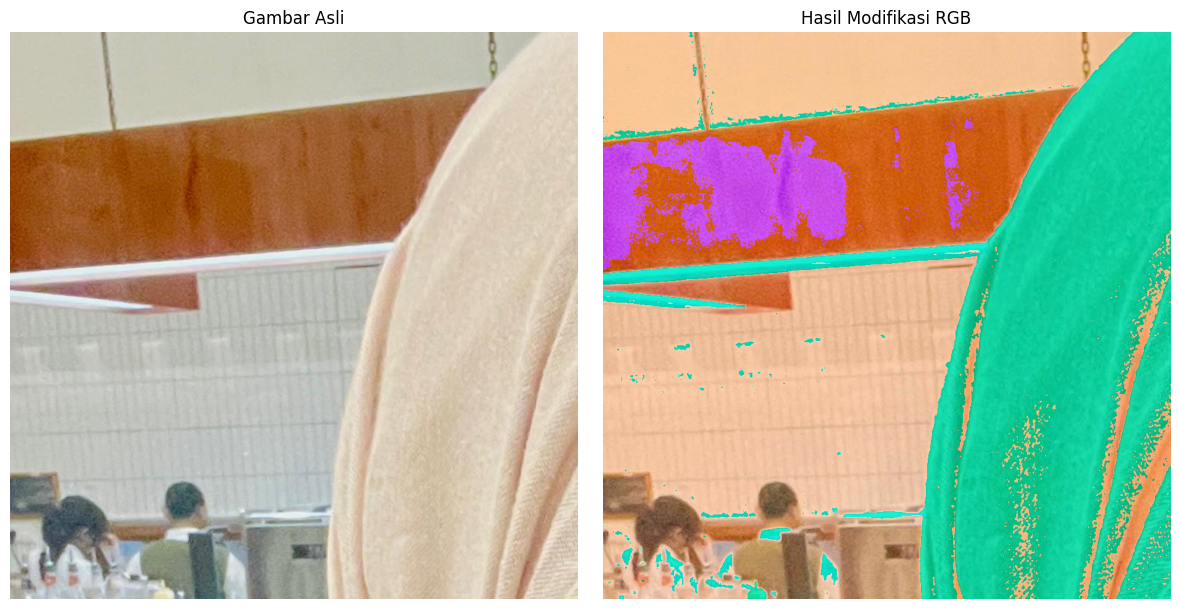

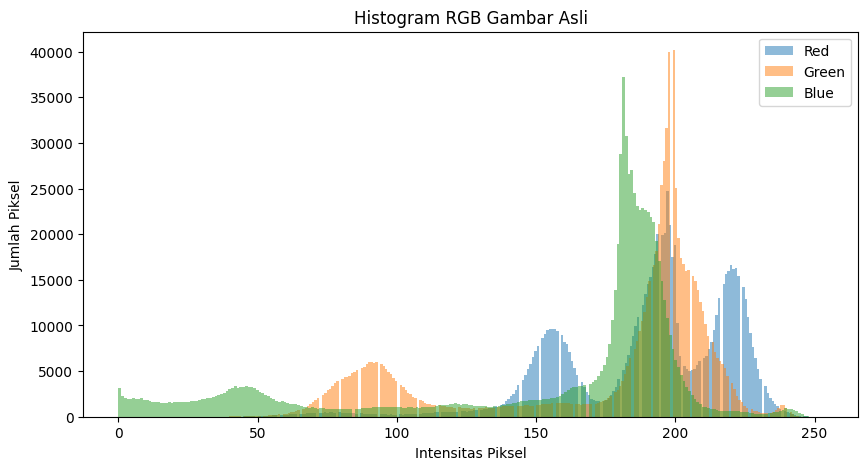

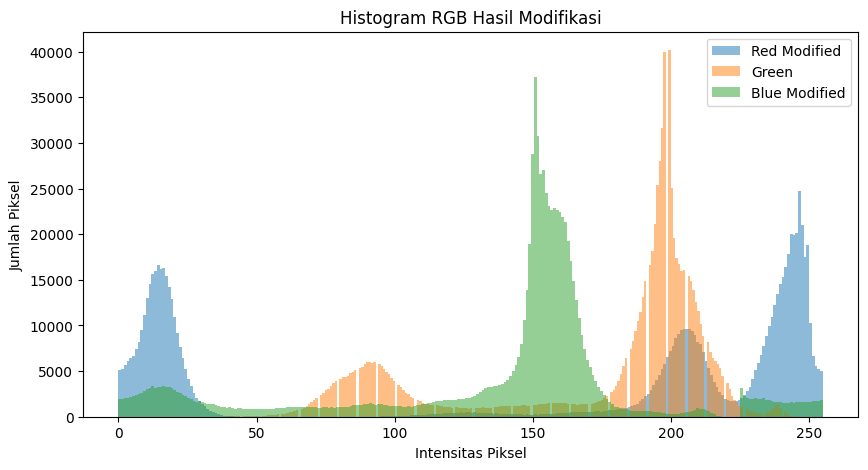

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# MEMBACA GAMBAR
# =====================================
img = cv2.imread(r".\assests_ws4\selfie11.jpeg")

# Cek gambar
if img is None:
    print("Gambar gagal dibaca")

else:

    # =====================================
    # KONVERSI BGR -> RGB
    # =====================================
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # =====================================
    # CROPPING WAJAH
    # =====================================
    crop_wajah = img_rgb[200:900, 50:700]

    # Resize 920x920
    crop_wajah = cv2.resize(crop_wajah, (920, 920))

    # =====================================
    # SPLIT CHANNEL RGB
    # =====================================
    R = crop_wajah[:, :, 0]
    G = crop_wajah[:, :, 1]
    B = crop_wajah[:, :, 2]

    # =====================================
    # MANIPULASI CHANNEL
    # =====================================

    # Naikkan merah +50
    R_mod = np.clip(R + 50, 0, 255)

    # Turunkan biru -30
    B_mod = np.clip(B - 30, 0, 255)

    # Hijau tetap
    G_mod = G

    # =====================================
    # GABUNGKAN CHANNEL
    # =====================================
    img_modified = cv2.merge((R_mod, G_mod, B_mod)).astype(np.uint8)

    # =====================================
    # SIMPAN GAMBAR PNG
    # =====================================
    save_img = cv2.cvtColor(img_modified, cv2.COLOR_RGB2BGR)

    cv2.imwrite("hasil_modifikasi_rgb.png", save_img)

    print("Gambar berhasil disimpan")

    # =====================================
    # TAMPILKAN GAMBAR
    # =====================================
    fig, axs = plt.subplots(1, 2, figsize=(12,6))

    axs[0].imshow(crop_wajah)
    axs[0].set_title("Gambar Asli")
    axs[0].axis('off')

    axs[1].imshow(img_modified)
    axs[1].set_title("Hasil Modifikasi RGB")
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

    # =====================================
    # HISTOGRAM GAMBAR ASLI
    # =====================================
    plt.figure(figsize=(10,5))

    plt.hist(R.ravel(), bins=256, alpha=0.5, label='Red')
    plt.hist(G.ravel(), bins=256, alpha=0.5, label='Green')
    plt.hist(B.ravel(), bins=256, alpha=0.5, label='Blue')

    plt.title("Histogram RGB Gambar Asli")
    plt.xlabel("Intensitas Piksel")
    plt.ylabel("Jumlah Piksel")
    plt.legend()

    plt.show()

    # =====================================
    # HISTOGRAM GAMBAR MODIFIKASI
    # =====================================
    plt.figure(figsize=(10,5))

    plt.hist(R_mod.ravel(), bins=256, alpha=0.5, label='Red Modified')
    plt.hist(G_mod.ravel(), bins=256, alpha=0.5, label='Green')
    plt.hist(B_mod.ravel(), bins=256, alpha=0.5, label='Blue Modified')

    plt.title("Histogram RGB Hasil Modifikasi")
    plt.xlabel("Intensitas Piksel")
    plt.ylabel("Jumlah Piksel")
    plt.legend()

    plt.show()

Pada kode tersebut dilakukan proses manipulasi channel warna RGB pada gambar hasil crop wajah. Tahap pertama dimulai dengan membaca gambar menggunakan OpenCV, kemudian gambar dikonversi dari format BGR ke RGB agar warna dapat ditampilkan dengan benar menggunakan matplotlib. Setelah itu dilakukan cropping pada area wajah menggunakan koordinat tertentu sehingga fokus gambar hanya berada pada bagian wajah pengguna. Hasil crop kemudian di-resize menjadi ukuran 920×920 piksel agar ukuran gambar lebih seragam dan mudah diproses.

Setelah proses cropping selesai, gambar dipisahkan menjadi tiga channel warna utama yaitu Red (R), Green (G), dan Blue (B) menggunakan indexing array NumPy. Pemisahan channel ini bertujuan agar setiap warna dapat dimanipulasi secara terpisah. Pada proses manipulasi warna, channel merah ditingkatkan sebesar 50 poin menggunakan operasi penjumlahan piksel. Sedangkan channel biru dikurangi sebesar 30 poin untuk mengurangi dominasi warna dingin pada gambar. Channel hijau dibiarkan tetap agar keseimbangan warna masih terjaga. Fungsi `np.clip()` digunakan untuk memastikan nilai piksel tetap berada dalam rentang 0–255 sehingga tidak terjadi overflow atau underflow pada data citra.

Setelah proses manipulasi selesai, ketiga channel warna digabungkan kembali menggunakan `cv2.merge()` sehingga menghasilkan gambar baru dengan warna yang telah dimodifikasi. Hasil gambar kemudian dikonversi kembali ke format BGR dan disimpan dalam file PNG menggunakan `cv2.imwrite()`. Format PNG dipilih karena mampu menyimpan kualitas gambar dengan baik tanpa kompresi berlebihan.

Pada bagian visualisasi, program menampilkan perbandingan antara gambar asli dan gambar hasil modifikasi RGB menggunakan matplotlib. Perubahan warna terlihat cukup jelas karena peningkatan channel merah membuat gambar tampak lebih hangat, sedangkan pengurangan channel biru membuat warna dingin menjadi berkurang. Efek ini menghasilkan tampilan wajah yang lebih cerah dan dominan kemerahan.

Selain menampilkan gambar, program juga membuat histogram RGB untuk gambar asli dan gambar hasil modifikasi menggunakan `matplotlib.pyplot.hist`. Histogram digunakan untuk melihat distribusi intensitas piksel pada setiap channel warna. Pada histogram hasil modifikasi terlihat bahwa distribusi channel merah bergeser ke kanan karena intensitas merah meningkat, sedangkan distribusi channel biru bergeser ke kiri akibat pengurangan intensitas biru. Histogram membantu dalam menganalisis perubahan warna secara visual dan memahami pengaruh manipulasi channel terhadap keseluruhan citra.

Teknik manipulasi channel RGB seperti ini sering digunakan dalam pengolahan citra digital untuk color correction, enhancement, filter warna, editing foto, dan preprocessing dataset computer vision.

### **Soal 3 — Deteksi Tepi dan Filter Citra**

* Ambil gambar **objek dengan background bertekstur** (misalnya kain bermotif, jerami, atau batu).
* Terapkan **edge detection (Canny)** dan tampilkan hasilnya.
* Lakukan **thresholding dengan nilai ambang tertentu** (bebas Anda tentukan) agar hanya objek utama yang tersisa.
* Buat **bounding box** di sekitar objek hasil segmentasi (boleh manual atau otomatis).
* Terapkan **filter blur** dan **filter sharpening**, lalu **bandingkan hasil keduanya**.
* Jelaskan bagaimana setiap filter memengaruhi detail gambar dalam format **Markdown**.


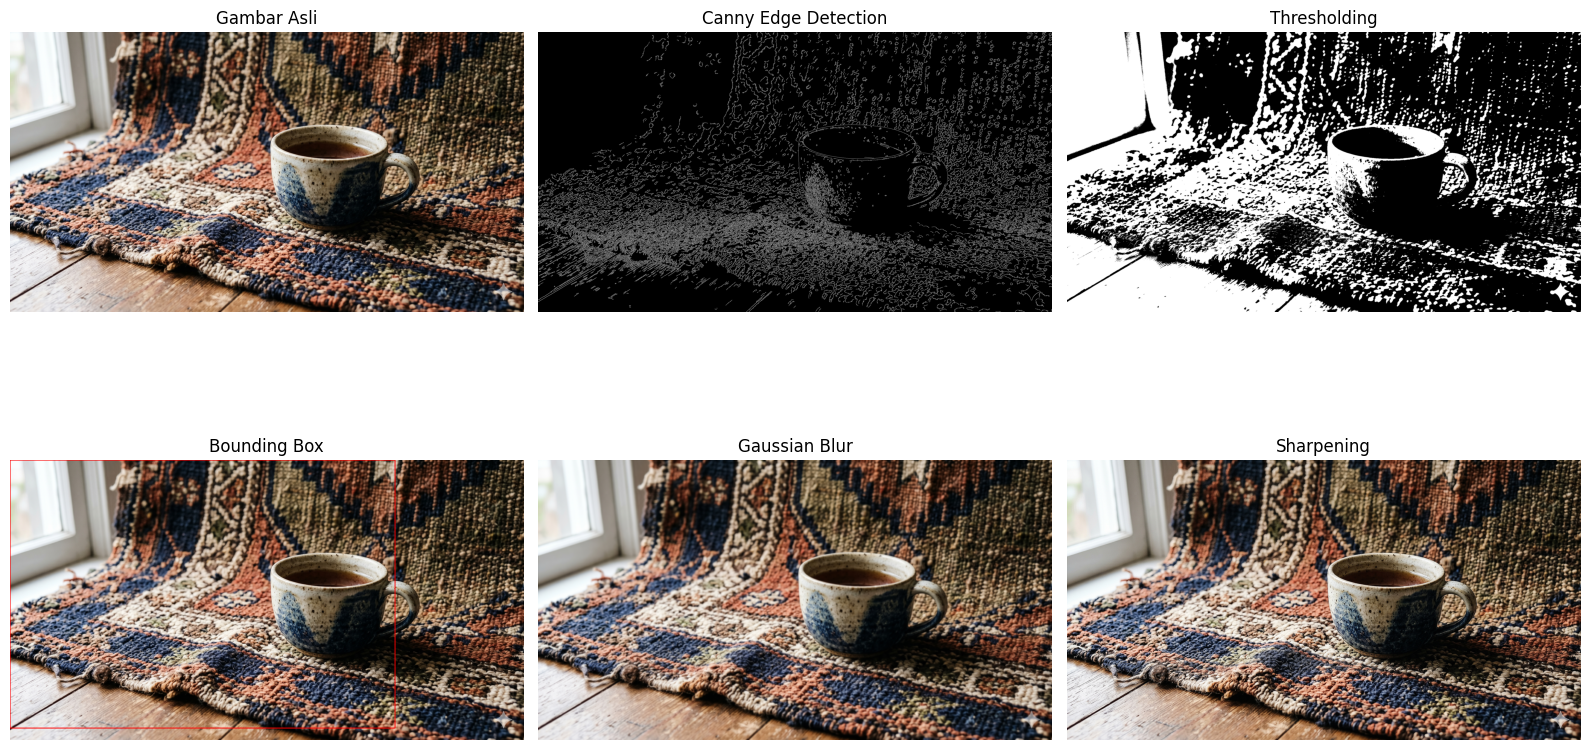

In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# MEMBACA GAMBAR
# =====================================
img = cv2.imread(r".\assests_ws4\mug.png")

# Cek gambar
if img is None:
    print("Gambar gagal dibaca")

else:

    # =====================================
    # KONVERSI BGR -> RGB
    # =====================================
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # =====================================
    # KONVERSI GRAYSCALE
    # =====================================
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # =====================================
    # EDGE DETECTION (CANNY)
    # =====================================
    edges = cv2.Canny(gray, 100, 200)

    # =====================================
    # THRESHOLDING
    # =====================================
    _, thresh = cv2.threshold(
        gray,
        120,
        255,
        cv2.THRESH_BINARY
    )

    # =====================================
    # CONTOUR DAN BOUNDING BOX
    # =====================================
    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # Copy gambar
    bbox_img = img_rgb.copy()

    # Cari contour terbesar
    if contours:

        largest_contour = max(contours, key=cv2.contourArea)

        x, y, w, h = cv2.boundingRect(largest_contour)

        # Bounding box
        cv2.rectangle(
            bbox_img,
            (x, y),
            (x + w, y + h),
            (255, 0, 0),
            3
        )

    # =====================================
    # FILTER BLUR
    # =====================================
    blur = cv2.GaussianBlur(
        img_rgb,
        (11,11),
        0
    )

    # =====================================
    # FILTER SHARPENING
    # =====================================
    kernel_sharp = np.array([
        [ 0, -1,  0],
        [-1,  5, -1],
        [ 0, -1,  0]
    ])

    sharpen = cv2.filter2D(
        img_rgb,
        -1,
        kernel_sharp
    )

    # =====================================
    # TAMPILKAN HASIL
    # =====================================
    fig, axs = plt.subplots(2, 3, figsize=(16,10))

    # Gambar asli
    axs[0,0].imshow(img_rgb)
    axs[0,0].set_title("Gambar Asli")
    axs[0,0].axis('off')

    # Edge Detection
    axs[0,1].imshow(edges, cmap='gray')
    axs[0,1].set_title("Canny Edge Detection")
    axs[0,1].axis('off')

    # Threshold
    axs[0,2].imshow(thresh, cmap='gray')
    axs[0,2].set_title("Thresholding")
    axs[0,2].axis('off')

    # Bounding Box
    axs[1,0].imshow(bbox_img)
    axs[1,0].set_title("Bounding Box")
    axs[1,0].axis('off')

    # Blur
    axs[1,1].imshow(blur)
    axs[1,1].set_title("Gaussian Blur")
    axs[1,1].axis('off')

    # Sharpen
    axs[1,2].imshow(sharpen)
    axs[1,2].set_title("Sharpening")
    axs[1,2].axis('off')

    plt.tight_layout()
    plt.show()

Pada kode tersebut dilakukan beberapa tahapan pengolahan citra untuk mendeteksi objek dan meningkatkan kualitas visual gambar mug. Tahap pertama adalah membaca gambar menggunakan OpenCV, kemudian gambar dikonversi dari format BGR ke RGB agar warna dapat ditampilkan dengan benar menggunakan matplotlib. Setelah itu, gambar juga dikonversi menjadi grayscale untuk menyederhanakan data citra sehingga proses analisis seperti edge detection dan thresholding menjadi lebih mudah dilakukan.

Proses berikutnya adalah edge detection menggunakan metode Canny. Teknik ini digunakan untuk mendeteksi tepi objek berdasarkan perubahan intensitas piksel yang signifikan. Hasil dari Canny Edge Detection menampilkan garis tepi objek mug sehingga bentuk objek menjadi lebih jelas dibandingkan gambar asli. Metode ini sangat berguna dalam proses segmentasi dan identifikasi bentuk objek pada citra digital.

Setelah deteksi tepi, dilakukan thresholding menggunakan `cv2.threshold()` dengan nilai ambang 120. Thresholding digunakan untuk memisahkan objek utama dengan background sehingga gambar berubah menjadi citra biner hitam putih. Piksel yang memiliki nilai di atas threshold akan berubah menjadi putih, sedangkan sisanya menjadi hitam. Teknik ini membantu memperjelas area objek dan mempermudah proses pencarian contour.

Tahap selanjutnya adalah pencarian contour dan pembuatan bounding box. Program mencari contour terbesar dari hasil thresholding menggunakan `cv2.findContours()`. Contour terbesar diasumsikan sebagai objek utama pada gambar, yaitu mug. Setelah contour ditemukan, program membuat bounding box menggunakan `cv2.boundingRect()` untuk menandai lokasi objek dengan kotak persegi panjang berwarna merah. Bounding box digunakan untuk menunjukkan area objek yang berhasil dideteksi.

Selain deteksi objek, kode ini juga menerapkan dua jenis filter citra yaitu Gaussian Blur dan Sharpening. Gaussian Blur digunakan untuk menghaluskan gambar dengan mengurangi noise dan detail-detail kecil menggunakan kernel berukuran `(11,11)`. Hasil blur membuat gambar terlihat lebih lembut tetapi detail objek menjadi berkurang. Sebaliknya, filter sharpening digunakan untuk mempertegas detail dan tepi objek menggunakan kernel khusus. Hasil sharpening membuat gambar terlihat lebih tajam dan detail objek menjadi lebih jelas dibandingkan gambar asli.

Pada bagian akhir, seluruh hasil pemrosesan ditampilkan dalam bentuk grid menggunakan matplotlib. Tampilan ini memudahkan pengguna untuk membandingkan hasil setiap tahap pengolahan citra mulai dari gambar asli, edge detection, thresholding, bounding box, blur, hingga sharpening. Teknik-teknik tersebut umum digunakan dalam computer vision, segmentasi objek, preprocessing citra, dan analisis visual digital.


### **Soal 4 — Deteksi Wajah dan Filter Digital Kreatif**

* Ambil gambar diri Anda dengan ekspresi wajah **netral**.
* Lakukan **deteksi wajah dan landmark** menggunakan salah satu dari:

  * **MediaPipe**, atau
  * **Dlib**, atau
  * **OpenCV**.
* Buat **overlay filter digital kreatif** karya Anda sendiri, misalnya:

  * topi, kumis, masker, helm, aksesoris, atau bentuk unik lainnya.
  * Filter boleh dibuat dari **gambar eksternal (PNG)** *atau* digambar langsung (misal bentuk lingkaran, garis, poligon, dll).
* Pastikan posisi overlay menyesuaikan **landmark wajah** dengan logis.
* **Gunakan alpha blending sebagai saran** agar hasil tampak lebih natural.
* Tampilkan perbandingan antara **gambar asli** dan **hasil dengan filter**.
* Jelaskan bagaimana Anda menghitung posisi overlay dan tantangan yang dihadapi selama implementasi (gunakan **Markdown**).

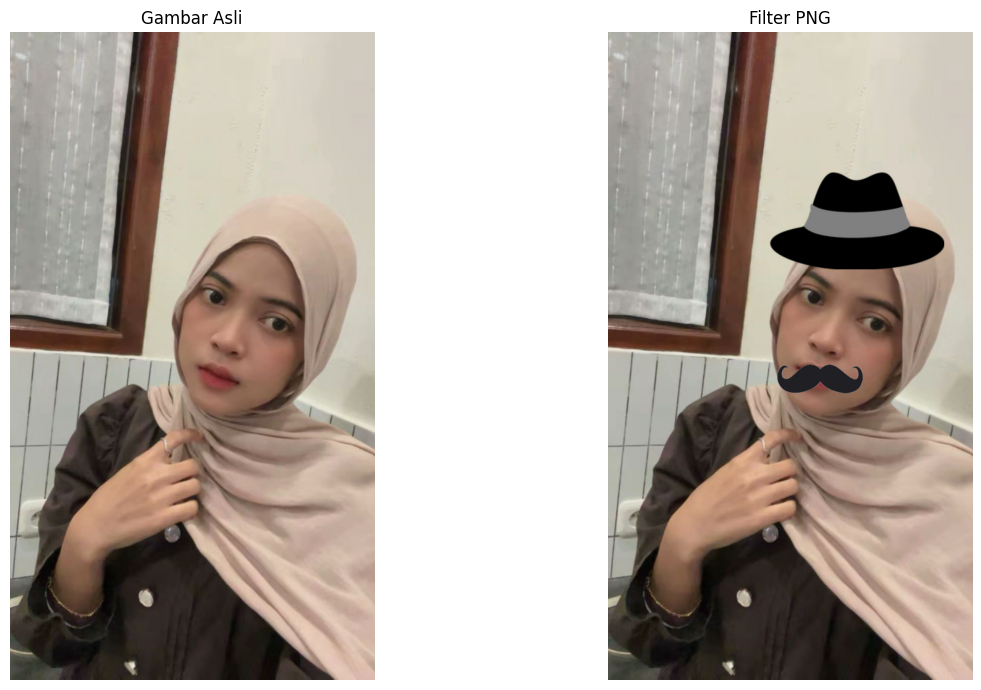

In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp

# =====================================
# MEMBACA GAMBAR UTAMA
# =====================================
img = cv2.imread(r".\assests_ws4\un.jpeg")

# =====================================
# MEMBACA FILTER PNG
# =====================================
# mustache.png = kumis transparan PNG
# hat.png = topi transparan PNG

mustache_png = cv2.imread(
    r".\assests_ws4\mustache.png",
    cv2.IMREAD_UNCHANGED
)

hat_png = cv2.imread(
    r".\assests_ws4\hat.png",
    cv2.IMREAD_UNCHANGED
)

# =====================================
# VALIDASI
# =====================================
if img is None:
    print("Gambar utama gagal dibaca")

elif mustache_png is None:
    print("Filter mustache.png gagal dibaca")

elif hat_png is None:
    print("Filter hat.png gagal dibaca")

else:

    # =====================================
    # KONVERSI BGR -> RGB
    # =====================================
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Copy output
    output = img_rgb.copy()

    # =====================================
    # MEDIAPIPE FACE MESH
    # =====================================
    mp_face_mesh = mp.solutions.face_mesh

    face_mesh = mp_face_mesh.FaceMesh(
        static_image_mode=True,
        max_num_faces=1,
        refine_landmarks=True,
        min_detection_confidence=0.5
    )

    # =====================================
    # DETEKSI WAJAH
    # =====================================
    results = face_mesh.process(img_rgb)

    # =====================================
    # FUNGSI OVERLAY PNG
    # =====================================
    def overlay_png(background, overlay, x, y):

        h, w = overlay.shape[:2]

        # Hindari keluar frame
        if y + h > background.shape[0]:
            h = background.shape[0] - y
            overlay = overlay[:h]

        if x + w > background.shape[1]:
            w = background.shape[1] - x
            overlay = overlay[:, :w]

        if x < 0:
            overlay = overlay[:, -x:]
            w = overlay.shape[1]
            x = 0

        if y < 0:
            overlay = overlay[-y:, :]
            h = overlay.shape[0]
            y = 0

        # Split alpha channel
        overlay_rgb = overlay[:, :, :3]
        alpha = overlay[:, :, 3] / 255.0

        # Area background
        bg = background[y:y+h, x:x+w]

        # Alpha blending
        for c in range(3):
            bg[:, :, c] = (
                alpha * overlay_rgb[:, :, c] +
                (1 - alpha) * bg[:, :, c]
            )

        background[y:y+h, x:x+w] = bg

        return background

    # =====================================
    # LANDMARK WAJAH
    # =====================================
    if results.multi_face_landmarks:

        for face_landmarks in results.multi_face_landmarks:

            h, w, c = img_rgb.shape

            # Landmark mata kiri & kanan
            left_eye = face_landmarks.landmark[33]
            right_eye = face_landmarks.landmark[263]

            # Landmark hidung
            nose = face_landmarks.landmark[1]

            # Landmark bibir atas
            upper_lip = face_landmarks.landmark[13]

            # Landmark dahi
            forehead = face_landmarks.landmark[10]

            # Konversi koordinat
            lx, ly = int(left_eye.x * w), int(left_eye.y * h)
            rx, ry = int(right_eye.x * w), int(right_eye.y * h)

            nx, ny = int(nose.x * w), int(nose.y * h)

            lip_x, lip_y = int(upper_lip.x * w), int(upper_lip.y * h)

            fx, fy = int(forehead.x * w), int(forehead.y * h)

            # =====================================
            # UKURAN KUMIS
            # =====================================
            mustache_width = abs(rx - lx)

            scale_mustache = (
                mustache_width /
                mustache_png.shape[1]
            )

            mustache_height = int(
                mustache_png.shape[0] *
                scale_mustache
            )

            resized_mustache = cv2.resize(
                mustache_png,
                (mustache_width, mustache_height)
            )

            # Posisi kumis
            mx = nx - mustache_width // 2
            my = lip_y - 25

            # Overlay kumis
            output = overlay_png(
                output,
                resized_mustache,
                mx,
                my
            )

            # =====================================
            # UKURAN TOPI
            # =====================================
            hat_width = abs(rx - lx) + 220

            scale_hat = hat_width / hat_png.shape[1]

            hat_height = int(
                hat_png.shape[0] *
                scale_hat
            )

            resized_hat = cv2.resize(
                hat_png,
                (hat_width, hat_height)
            )

            # Posisi topi
            hx = fx - hat_width // 2
            hy = fy - hat_height

            # Overlay topi
            output = overlay_png(
                output,
                resized_hat,
                hx,
                hy
            )

    # =====================================
    # TAMPILKAN HASIL
    # =====================================
    fig, axs = plt.subplots(1, 2, figsize=(14,7))

    # Gambar asli
    axs[0].imshow(img_rgb)
    axs[0].set_title("Gambar Asli")
    axs[0].axis('off')

    # Hasil filter
    axs[1].imshow(output)
    axs[1].set_title("Filter PNG")
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

Pada program ini dilakukan proses deteksi wajah menggunakan MediaPipe Face Mesh untuk menambahkan filter digital berupa topi dan kumis dari file PNG transparan. Gambar utama terlebih dahulu dibaca menggunakan OpenCV, kemudian dikonversi dari format BGR ke RGB agar dapat diproses dengan benar oleh MediaPipe dan ditampilkan menggunakan matplotlib. Setelah gambar berhasil dimuat, program juga membaca dua file filter PNG yaitu `mustache.png` dan `hat.png` menggunakan mode `cv2.IMREAD_UNCHANGED`. Mode ini digunakan agar channel alpha atau transparansi pada gambar PNG tetap terbaca sehingga filter dapat menyatu secara lebih natural dengan wajah melalui teknik alpha blending.

Tahap berikutnya adalah proses deteksi landmark wajah menggunakan MediaPipe Face Mesh. Model ini mendeteksi berbagai titik penting pada wajah seperti mata, hidung, bibir, dan dahi. Pada implementasi ini, landmark mata kiri dan kanan digunakan untuk menentukan ukuran wajah, landmark hidung dan bibir atas digunakan untuk menentukan posisi kumis, sedangkan landmark dahi digunakan untuk menentukan posisi topi. Koordinat landmark yang diperoleh masih berupa rasio sehingga perlu dikonversi menjadi koordinat piksel berdasarkan ukuran gambar asli. Jarak antara kedua mata digunakan sebagai acuan untuk menghitung ukuran filter agar tetap proporsional dengan ukuran wajah pengguna.

Filter PNG kemudian ditempelkan ke gambar utama menggunakan fungsi `overlay_png()`. Fungsi ini bertugas menyesuaikan ukuran filter, memastikan filter tidak keluar dari area gambar, memisahkan channel RGB dan alpha pada PNG, lalu menggabungkannya dengan gambar utama menggunakan alpha blending. Teknik alpha blending membuat hasil overlay terlihat lebih halus dan realistis karena tingkat transparansi filter ikut diperhitungkan saat proses penggabungan citra.

Pada filter kumis, posisi overlay dihitung menggunakan titik hidung dan bibir atas agar kumis berada tepat di bawah hidung. Sementara itu, filter topi ditempatkan berdasarkan posisi dahi sehingga topi berada di atas kepala dengan ukuran yang menyesuaikan lebar wajah. Hasil akhir program menampilkan perbandingan antara gambar asli dan gambar yang telah diberi filter digital. Teknik seperti ini banyak digunakan pada augmented reality (AR), filter media sosial, face tracking, virtual makeup, serta berbagai aplikasi computer vision interaktif lainnya. Tantangan utama dalam implementasi ini adalah menentukan posisi overlay agar tetap sesuai pada berbagai ukuran dan bentuk wajah, serta menjaga agar ukuran dan posisi filter terlihat natural dan tidak keluar dari area wajah.

### **Soal 5 — Perspektif dan Peningkatan Kualitas Citra**

* Ambil gambar **objek datar** seperti karya tangan di kertas, tulisan di papan tulis, atau foto produk di meja dengan kondisi pencahayaan atau sudut yang tidak ideal.
* Lakukan **preprocessing** untuk memperbaiki tampilan agar lebih rapi dan jelas, dengan langkah-langkah:

  * Konversi ke **grayscale**.
  * **Koreksi perspektif (transformasi homografi)** menggunakan **4 titik manual** agar objek terlihat sejajar dan tidak terdistorsi.
  * Terapkan **thresholding adaptif atau Otsu** (pilih salah satu, dan jelaskan alasan pilihan Anda).
* Tampilkan **setiap tahap pemrosesan dalam satu grid** agar mudah dibandingkan.
* Jelaskan fungsi masing-masing tahap dan bagaimana teknik ini meningkatkan kualitas visual citra (gunakan **Markdown**).

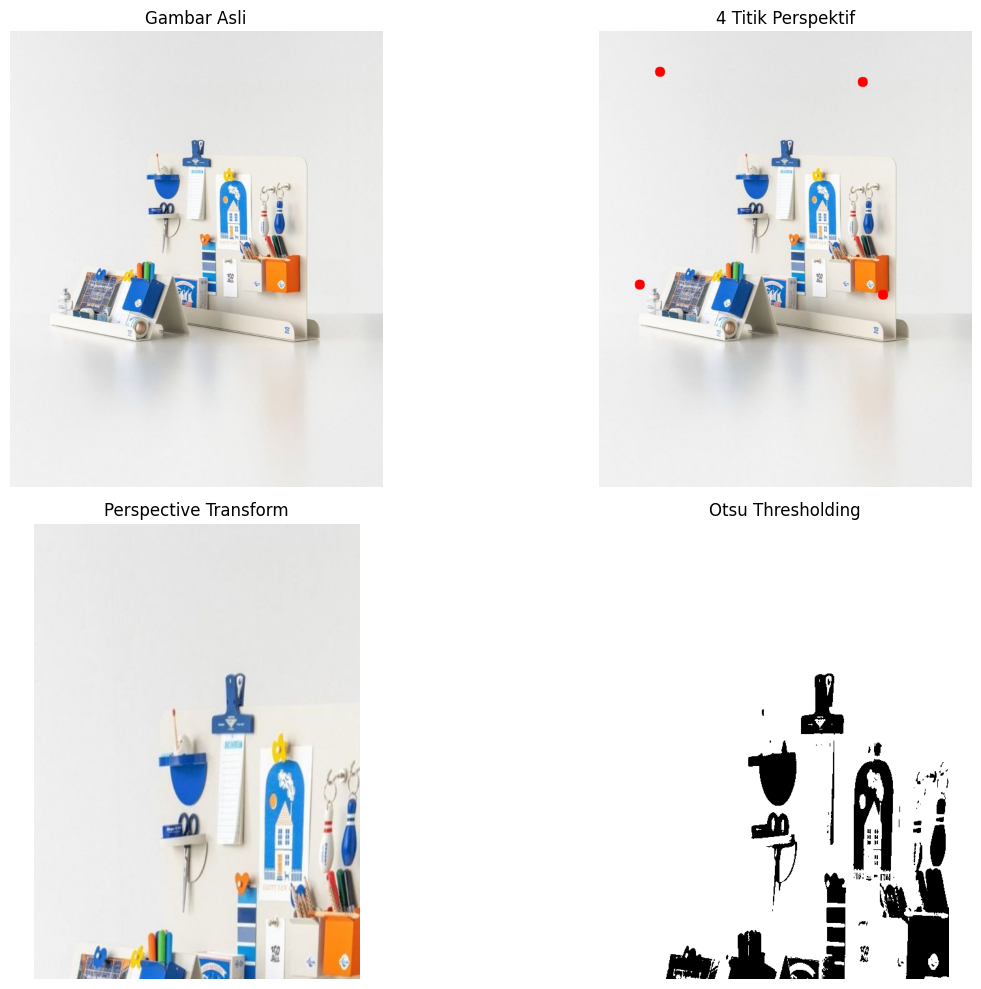

In [38]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# MEMBACA GAMBAR
# =====================================
img = cv2.imread(r".\assests_ws4\w.jpg")

# Cek gambar
if img is None:
    print("Gambar gagal dibaca")

else:

    # =====================================
    # KONVERSI BGR -> RGB
    # =====================================
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # =====================================
    # GRAYSCALE
    # =====================================
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # =====================================
    # TITIK PERSPEKTIF MANUAL
    # Sesuaikan dengan posisi objek
    # =====================================

    pts1 = np.float32([
        [120, 80],    # kiri atas
        [520, 100],   # kanan atas
        [80, 500],    # kiri bawah
        [560, 520]    # kanan bawah
    ])

    # Ukuran output
    width = 500
    height = 700

    pts2 = np.float32([
        [0, 0],
        [width, 0],
        [0, height],
        [width, height]
    ])

    # =====================================
    # HOMOGRAFI / PERSPEKTIF
    # =====================================
    matrix = cv2.getPerspectiveTransform(pts1, pts2)

    warped = cv2.warpPerspective(
        img_rgb,
        matrix,
        (width, height)
    )

    # =====================================
    # GRAYSCALE HASIL WARP
    # =====================================
    warped_gray = cv2.cvtColor(
        warped,
        cv2.COLOR_RGB2GRAY
    )

    # =====================================
    # OTSU THRESHOLDING
    # =====================================
    _, otsu = cv2.threshold(
        warped_gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # =====================================
    # VISUALISASI TITIK PERSPEKTIF
    # =====================================
    point_img = img_rgb.copy()

    for point in pts1:
        x, y = point.astype(int)

        cv2.circle(
            point_img,
            (x, y),
            10,
            (255, 0, 0),
            -1
        )

    # =====================================
    # TAMPILKAN GRID
    # =====================================
    fig, axs = plt.subplots(2, 2, figsize=(14,10))

    # Gambar asli
    axs[0,0].imshow(img_rgb)
    axs[0,0].set_title("Gambar Asli")
    axs[0,0].axis('off')

    # Titik perspektif
    axs[0,1].imshow(point_img)
    axs[0,1].set_title("4 Titik Perspektif")
    axs[0,1].axis('off')

    # Hasil homografi
    axs[1,0].imshow(warped)
    axs[1,0].set_title("Perspective Transform")
    axs[1,0].axis('off')

    # Otsu Threshold
    axs[1,1].imshow(otsu, cmap='gray')
    axs[1,1].set_title("Otsu Thresholding")
    axs[1,1].axis('off')

    plt.tight_layout()
    plt.show()


Pada proses preprocessing citra, tahap pertama yang dilakukan adalah konversi gambar RGB menjadi grayscale. Proses grayscale digunakan untuk menyederhanakan citra dengan menghilangkan informasi warna dan hanya mempertahankan intensitas cahaya pada setiap piksel. Dengan menggunakan grayscale, proses analisis citra menjadi lebih mudah karena jumlah data yang diproses berkurang. Selain itu, proses thresholding dan transformasi citra dapat dilakukan dengan lebih cepat dan efisien.

Tahap berikutnya adalah perspective transform atau homografi. Teknik ini digunakan untuk memperbaiki sudut pandang gambar agar objek terlihat lebih lurus dan sejajar. Pada praktikum ini digunakan empat titik manual yang diambil dari sudut objek sebagai acuan transformasi perspektif menggunakan fungsi `cv2.getPerspectiveTransform()`. Setelah dilakukan transformasi, objek terlihat seperti dipindai dari arah atas sehingga distorsi perspektif dapat dikurangi. Hasilnya membuat tampilan objek menjadi lebih rapi, garis terlihat lebih lurus, dan citra tampak lebih profesional.

Selanjutnya diterapkan metode Otsu Thresholding untuk memisahkan foreground dan background secara otomatis berdasarkan distribusi histogram intensitas piksel. Metode Otsu dipilih karena tidak memerlukan nilai threshold manual sehingga lebih praktis digunakan pada kondisi pencahayaan yang kurang ideal. Teknik ini sangat cocok untuk dokumen atau objek datar karena mampu memperjelas objek utama dan mengurangi gangguan dari background. Setelah thresholding dilakukan, gambar berubah menjadi hitam putih sehingga teks atau bentuk objek menjadi lebih jelas dan mudah dianalisis.

Gabungan dari seluruh tahapan preprocessing tersebut mampu meningkatkan kualitas visual citra secara signifikan. Distorsi perspektif dapat dikurangi, objek utama menjadi lebih jelas, dan detail penting lebih mudah dikenali. Teknik seperti ini banyak digunakan pada scanner dokumen, OCR (Optical Character Recognition), preprocessing dataset computer vision, digitalisasi arsip, serta berbagai aplikasi pengolahan citra digital lainnya.

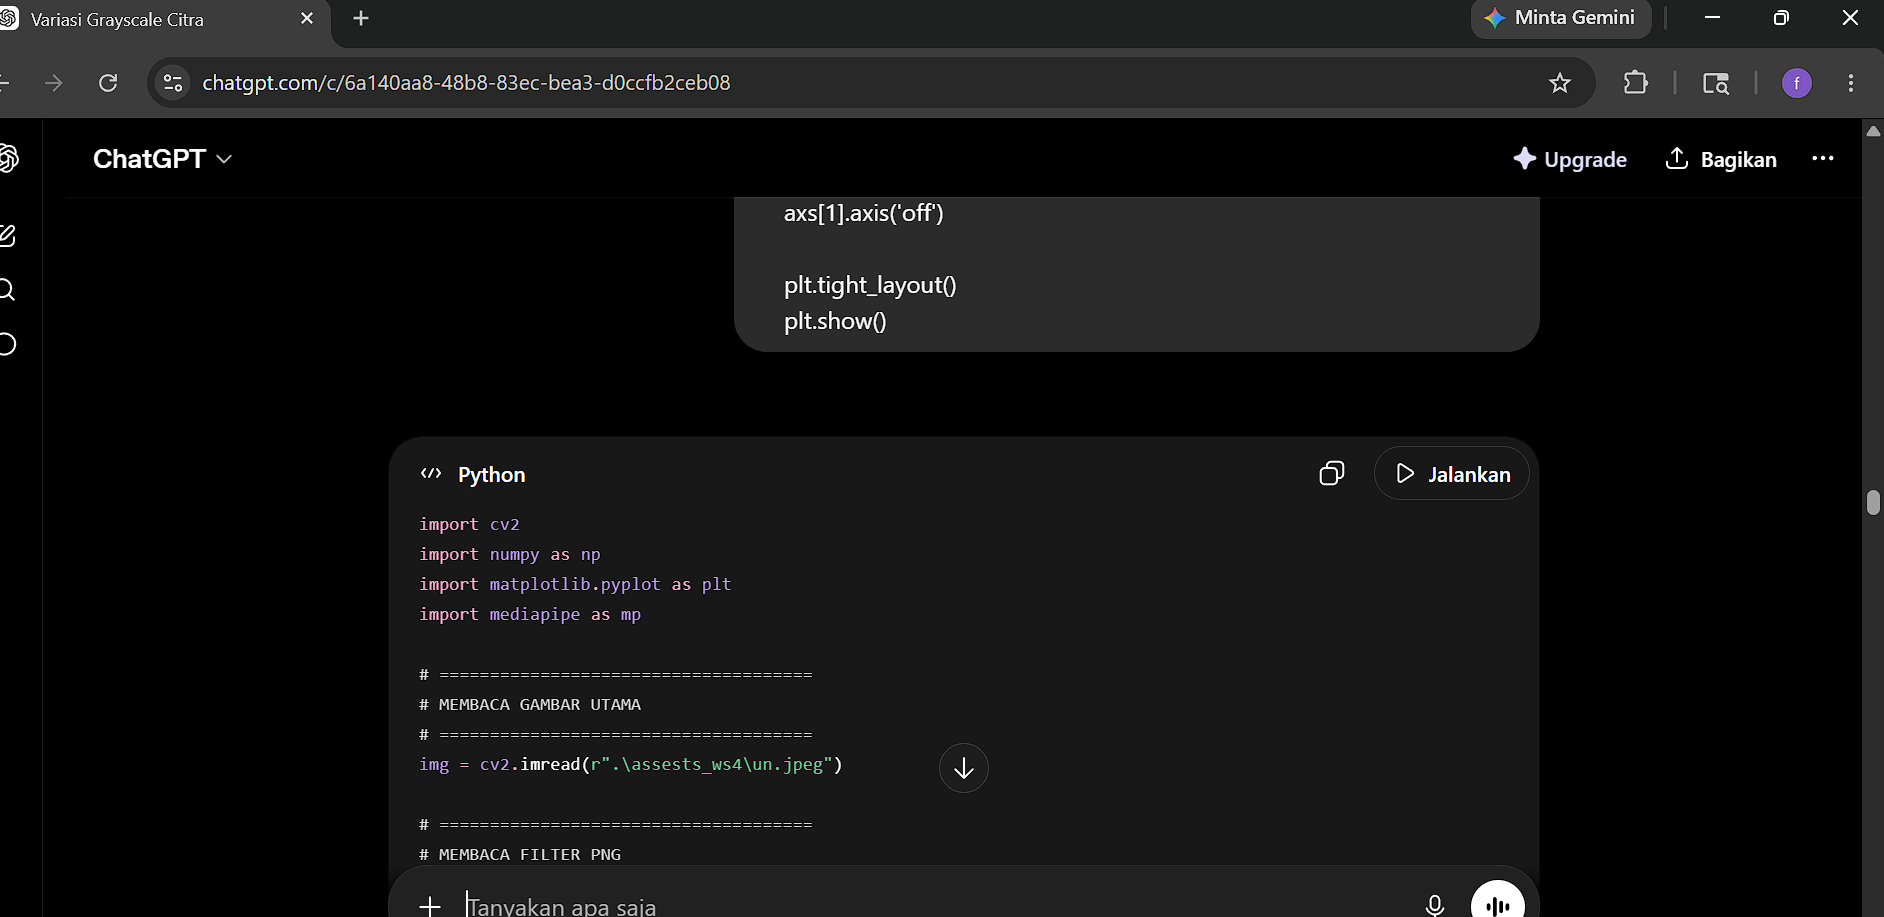
AI menggunakan ChatGPT

## **Reference**
-https://github.com/Py-Contributors/Face_Filter/tree/fastapi-version/filters

-https://www.reddit.com/r/opencv/comments/ud191u/findcontour_does_not_find_the_right_contour

-https://docs.opencv.org/3.4/da/d0c/tutorial_bounding_rects_circles.html

### **Aturan Umum Pengerjaan**

* Kerjakan secara **mandiri**.
* Bantuan AI (seperti ChatGPT, Copilot, dsb.) diperbolehkan **dengan bukti percakapan** (screenshot / link / script percakapan).
* Source code antar mahasiswa harus berbeda.
* Jika mendapat bantuan teman, tuliskan nama dan NIM teman yang membantu.
* Plagiarisme akan dikenakan sanksi sesuai aturan akademik ITERA.
* Cantumkan seluruh **credit dan referensi** yang digunakan di bagian akhir notebook.
* Penjelasan setiap soal ditulis dalam **Markdown**, bukan di dalam komentar kode.

---

### **Aturan Pengumpulan**

* Semua file kerja Anda (notebook `.ipynb`, gambar, dan hasil) **wajib diunggah ke GitHub repository tugas sebelumnya**.

  * Gunakan struktur folder berikut di dalam repo Anda:

    ```
    /Nama_NIM_Repo/ # Nama repo sebelumnya
      ├── assets_ws4/     # berisi semua gambar atau video asli (input)
      ├── results_ws4/    # berisi semua hasil modifikasi dan output
      ├── worksheet4.ipynb
      └── NIM_Worksheet4.pdf
    ```
* File yang dikumpulkan ke **Tally** hanya berupa **hasil PDF** dari notebook Anda, dengan format nama:

  ```
  NIM_Worksheet4.pdf
  ```
* Pastikan notebook telah dijalankan penuh sebelum diekspor ke PDF.
* Sertakan tautan ke repository GitHub Anda di bagian atas notebook atau di halaman pertama PDF.

---

### ✅ **Catatan Akhir**

> Worksheet 4 ini bertujuan mengasah pemahaman Anda tentang manipulasi citra digital secara praktis. Gunakan kreativitas Anda untuk menghasilkan hasil visual yang menarik dan penjelasan konseptual yang jelas.